목표 : MSE 손실함수값 3000 이하를 달성

In [419]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np

data = load_diabetes()
df_X = data.data
df_y = data.target

In [420]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


age sex .... s6의 값(10개의 데이터)을 통해 target(당뇨병)의 값을 예측 해야한다.

In [421]:
X = np.array(df_X)
y = np.array(df_y)

print(type(X), X.dtype)
print(type(y), y.dtype)

<class 'numpy.ndarray'> float64
<class 'numpy.ndarray'> float64


### numpy array로 변환하는 이유

판다스(Pandas) 표나 파이썬 리스트 형태보다 넘파이 배열(NumPy Array)이 수학 연산 및 머신러닝 모델에 훨씬 적합하기 때문
실무에서 분석이나 전처리를 할 때는 판다스 표(DataFrame)로 편하게 작업하지만, 최종적으로 모델에 집어넣어 학습시킬 때는 항상 넘파이 배열(ndarray) 형태로 변환되어 들어가게 됩니다.

#### 1. 가장 전통적인 방식 (이미지 문제에서 사용한 방식)
X = np.array(df_X)

#### 2. 실무에서 아주 흔히 쓰는 간결한 속성 표현
X = df_X.values

#### 3. 최신 판다스 권장 방식
X = df_X.to_numpy()

출처 : 제미나이

In [422]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [423]:
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

10


In [424]:
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

In [425]:
def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

In [426]:
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [427]:
def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

In [428]:
LEARNING_RATE = 0.01

In [429]:
%%timeit
global W, b

losses = []

for i in range(1, 1001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 6400.9532
Iteration 200 : Loss 5916.8311
Iteration 300 : Loss 5836.0700
Iteration 400 : Loss 5764.6406
Iteration 500 : Loss 5695.5373
Iteration 600 : Loss 5628.5634
Iteration 700 : Loss 5563.6449
Iteration 800 : Loss 5500.7123
Iteration 900 : Loss 5439.6985
Iteration 1000 : Loss 5380.5387
Iteration 100 : Loss 5323.1704
Iteration 200 : Loss 5267.5334
Iteration 300 : Loss 5213.5695
Iteration 400 : Loss 5161.2225
Iteration 500 : Loss 5110.4381
Iteration 600 : Loss 5061.1641
Iteration 700 : Loss 5013.3500
Iteration 800 : Loss 4966.9469
Iteration 900 : Loss 4921.9079
Iteration 1000 : Loss 4878.1876
Iteration 100 : Loss 4835.7419
Iteration 200 : Loss 4794.5288
Iteration 300 : Loss 4754.5072
Iteration 400 : Loss 4715.6378
Iteration 500 : Loss 4677.8825


Iteration 600 : Loss 4641.2045
Iteration 700 : Loss 4605.5684
Iteration 800 : Loss 4570.9399
Iteration 900 : Loss 4537.2859
Iteration 1000 : Loss 4504.5746
Iteration 100 : Loss 4472.7750
Iteration 200 : Loss 4441.8574
Iteration 300 : Loss 4411.7932
Iteration 400 : Loss 4382.5545
Iteration 500 : Loss 4354.1146
Iteration 600 : Loss 4326.4476
Iteration 700 : Loss 4299.5285
Iteration 800 : Loss 4273.3333
Iteration 900 : Loss 4247.8386
Iteration 1000 : Loss 4223.0220
Iteration 100 : Loss 4198.8617
Iteration 200 : Loss 4175.3367
Iteration 300 : Loss 4152.4269
Iteration 400 : Loss 4130.1126
Iteration 500 : Loss 4108.3750
Iteration 600 : Loss 4087.1958
Iteration 700 : Loss 4066.5574
Iteration 800 : Loss 4046.4428
Iteration 900 : Loss 4026.8356
Iteration 1000 : Loss 4007.7197
Iteration 100 : Loss 3989.0801
Iteration 200 : Loss 3970.9017
Iteration 300 : Loss 3953.1702
Iteration 400 : Loss 3935.8720
Iteration 500 : Loss 3918.9935
Iteration 600 : Loss 3902.5219
Iteration 700 : Loss 3886.4447
Itera

%%timeit -n 1 -r 1  --> %%timeit 이렇게 바꾼 결과 mse의 값이 5300 -> 3189 변경
반복문을 1000회에서 2000회로 증가 시킨 결과 3189 -> 2944 변경

%%timeit 을 사용하면 더 많은 학습을하여 3189까지 하락 하는 것으로 추정
단 %%time , %%timeit -n 1 -r 1 , 주석처리를 한 경우 똑같이 5160~5370 사이로 값이 나옴



In [430]:
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(2876.9014812883825)

%%timeit -n 1 -r 1 + LEARNING_RATE = 0.01  + 10000회 반복 기준으로 mse : 3090
%%timeit + LEARNING_RATE = 0.001 + 1000회 반복 기준으로 mse : 3189
%%timeit + LEARNING_RATE = 0.001 + 2000회 반복 기준으로 mse : 2944
%%timeit + LEARNING_RATE = 0.01  + 1000회 반복 기준으로 mse : 2876
%%timeit + LEARNING_RATE = 0.01  + 10000회 반복 기준으로 mse : 2876
%%timeit + LEARNING_RATE = 0.1   + 1000회 반복 기준으로 mse : 2886

반복이 많으면 mse의 값도 떨어질 거라고 생각 했지만 생각과는 다르게 값이 똑같이 나왔습니다. 일정 이상 학습을 하면 더이상 내려가지 않습니다.

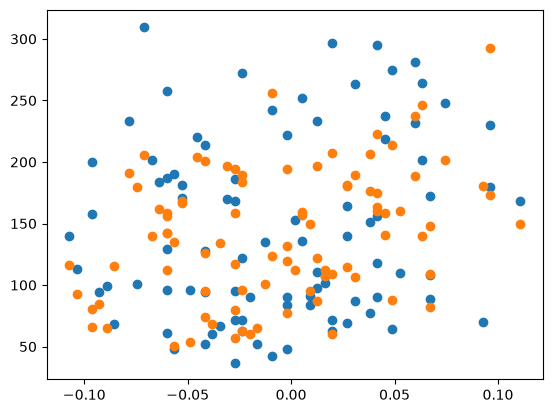

In [431]:
import matplotlib.pyplot as plt

plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()

%%timeit + LEARNING_RATE = 0.01  + 1000회 반복 기준으로 mse : 2876 이였지만

기존코드
```bash
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
```
변경 코드  test_size= 0.2 -> 0.1
```bash
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)
```
이 부분의 test_size의 값을 0.1로 변경했더니 mse : 2737 까지 떨어진 걸 확인 했습니다.

학습과 반복을 변경할 때 마다 mse가 줄어드는 결과를 보는게 상당히 재미있었습니다.
2700 아래 까지 만들어보고 싶었지만 이 이상 어떻게 떨어트려야 할지 모르겠습니다.
하지만 이 부분을 보고 테스트 값이 너무 적어서 떨어진게 아닌가? 라는 생각도 들었습니다.

값을 어떻게 바꾸냐에 따라 오차를 어떻게 줄여나가는지 생각하는 부분이 좋았습니다.